Goal:
Train the same 2‑layer NN using vanilla SGD, SGD+Momentum, and Adam, then compare:

Convergence speed (loss vs steps),

Stability (variance of the curve),

Final performance (accuracy).

We’ll reuse a small non‑linear 2D dataset and a 2‑layer MLP (ReLU).

In [1]:
# pip install numpy matplotlib
import numpy as np, matplotlib.pyplot as plt
np.random.seed(0)

1) Toy data (rings) + helpers

In [2]:
def make_rings(n_inner=400, n_outer=400, noise=0.15, r_inner=0.8, r_outer=2.0):
    th1, th2 = 2*np.pi*np.random.rand(n_inner), 2*np.pi*np.random.rand(n_outer)
    X1 = np.c_[r_inner*np.cos(th1), r_inner*np.sin(th1)] + noise*np.random.randn(n_inner,2)
    X2 = np.c_[r_outer*np.cos(th2), r_outer*np.sin(th2)] + noise*np.random.randn(n_outer,2)
    X = np.vstack([X1, X2]); y = np.r_[np.zeros(n_inner, int), np.ones(n_outer, int)]
    p = np.random.permutation(len(X)); return X[p], y[p]
 
X, y = make_rings()
N, D, K = X.shape[0], 2, 2
 
# train/val split
cut = int(0.8*N)
Xtr, ytr = X[:cut], y[:cut]
Xte, yte = X[cut:], y[cut:]
 
def one_hot(y, K): 
    Y = np.zeros((y.size, K)); Y[np.arange(y.size), y] = 1; return Y
 
def relu(z): return np.maximum(0.0, z)
def d_relu(z): return (z>0).astype(float)
 
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z); return e / e.sum(axis=1, keepdims=True)
 
def accuracy(y, P): return (P.argmax(1) == y).mean()

2) Model (2‑layer MLP) + forward/backprop

In [3]:
def init_params(D=2, H=32, K=2):
    return {
        "W1": np.random.randn(D, H) * np.sqrt(2.0/D),
        "b1": np.zeros((1, H)),
        "W2": np.random.randn(H, K) * np.sqrt(2.0/H),
        "b2": np.zeros((1, K)),
    }
 
def forward(X, p):
    Z1 = X @ p["W1"] + p["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ p["W2"] + p["b2"]
    P  = softmax(Z2)
    cache = {"X":X, "Z1":Z1, "A1":A1, "Z2":Z2, "P":P}
    return P, cache
 
def loss_ce(P, Y, l2, p):
    eps=1e-12
    L = -np.sum(Y*np.log(P+eps))/P.shape[0]
    if l2>0: L += 0.5*l2*(np.sum(p["W1"]**2)+np.sum(p["W2"]**2))
    return L
 
def backward(cache, Y, p, l2):
    X, Z1, A1, P = cache["X"], cache["Z1"], cache["A1"], cache["P"]
    N = X.shape[0]
    dZ2 = (P - Y)/N
    dW2 = A1.T @ dZ2 + l2*p["W2"]
    db2 = dZ2.sum(0, keepdims=True)
    dA1 = dZ2 @ p["W2"].T
    dZ1 = dA1 * d_relu(Z1)
    dW1 = X.T @ dZ1 + l2*p["W1"]
    db1 = dZ1.sum(0, keepdims=True)
    return {"W1":dW1,"b1":db1,"W2":dW2,"b2":db2}

Optimizers (SGD, Momentum, Adam)

In [4]:
def sgd_update(p, g, lr, state):  # no state
    for k in p: p[k] -= lr * g[k]
    return state
 
def momentum_update(p, g, lr, state, beta=0.9):
    if not state: state = {k: np.zeros_like(p[k]) for k in p}
    for k in p:
        state[k] = beta*state[k] + (1-beta)*g[k]
        p[k]    -= lr * state[k]
    return state
 
def adam_update(p, g, lr, state, b1=0.9, b2=0.999, eps=1e-8):
    if not state:
        state = {"m":{k:np.zeros_like(p[k]) for k in p},
                 "v":{k:np.zeros_like(p[k]) for k in p},
                 "t":0}
    state["t"] += 1
    t = state["t"]
    for k in p:
        state["m"][k] = b1*state["m"][k] + (1-b1)*g[k]
        state["v"][k] = b2*state["v"][k] + (1-b2)*(g[k]**2)
        mhat = state["m"][k] / (1 - b1**t)
        vhat = state["v"][k] / (1 - b2**t)
        p[k] -= lr * mhat / (np.sqrt(vhat) + eps)
    return state

 Training loop (shared) + run all optimizers

In [5]:
def train_with_optimizer(opt_name, updater, lr, epochs=1500, batch=128, H=32, l2=1e-4, seed=0):
    rng = np.random.default_rng(seed)
    p = init_params(D=2, H=H, K=2)
    state = {}
    Ytr = one_hot(ytr, 2)
    hist = {"loss":[], "acc_tr":[], "acc_te":[]}
 
    for ep in range(1, epochs+1):
        idx = rng.choice(len(Xtr), size=min(batch, len(Xtr)), replace=False)
        Xb, Yb = Xtr[idx], Ytr[idx]
        P, cache = forward(Xb, p)
        L = loss_ce(P, Yb, l2, p)
        g = backward(cache, Yb, p, l2)
 
        state = updater(p, g, lr, state)  # optimizer step
 
        if ep==1 or ep%50==0:
            Ptr,_ = forward(Xtr, p); Pte,_ = forward(Xte, p)
            hist["loss"].append(L)
            hist["acc_tr"].append(accuracy(ytr, Ptr))
            hist["acc_te"].append(accuracy(yte, Pte))
    return p, hist
 
# Sensible default lrs (often: SGD needs larger lr, Adam smaller)
runs = {
    "SGD":      dict(updater=sgd_update,      lr=0.10),
    "Momentum": dict(updater=momentum_update, lr=0.08),
    "Adam":     dict(updater=adam_update,     lr=0.01),
}
 
results = {}
for name, cfg in runs.items():
    p, hist = train_with_optimizer(name, **cfg, epochs=1500, batch=128, H=32, l2=1e-4, seed=0)
    results[name] = (p, hist)
    print(f"{name:8s} | final train acc={hist['acc_tr'][-1]:.3f}  val acc={hist['acc_te'][-1]:.3f}")

SGD      | final train acc=1.000  val acc=1.000
Momentum | final train acc=1.000  val acc=1.000
Adam     | final train acc=1.000  val acc=1.000


5) Plot convergence

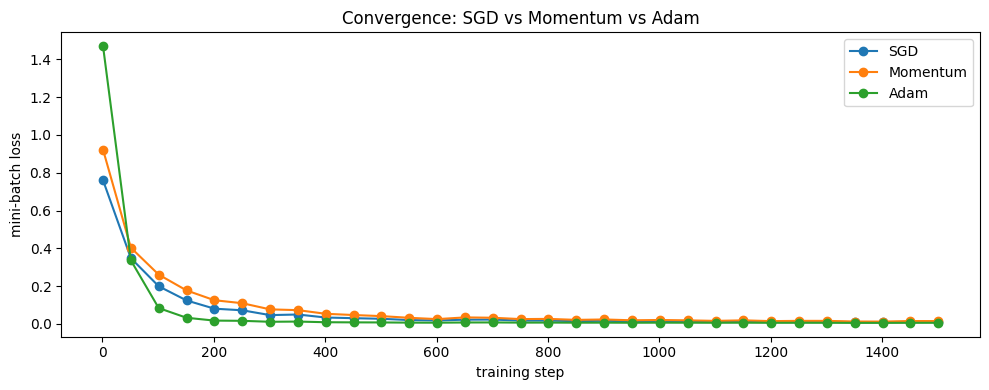

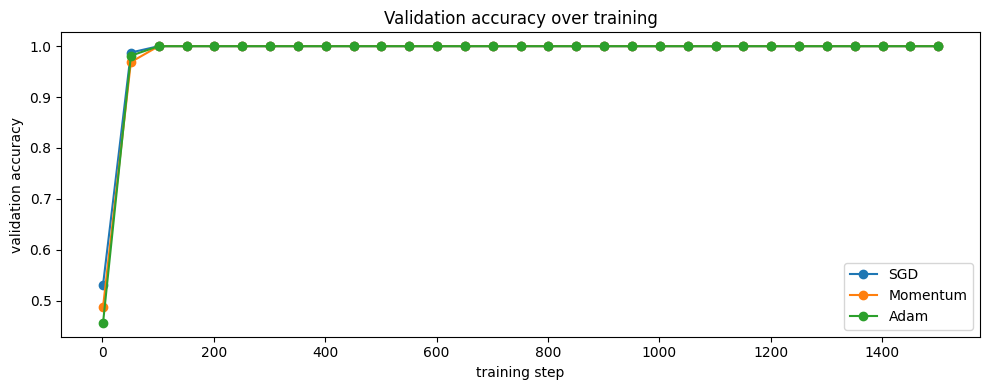

In [6]:
steps = np.arange(len(next(iter(results.values()))[1]["loss"])) * 50 + 1
plt.figure(figsize=(10,4))
for name, (_, h) in results.items():
    plt.plot(steps, h["loss"], marker='o', label=name)
plt.xlabel("training step"); plt.ylabel("mini-batch loss")
plt.title("Convergence: SGD vs Momentum vs Adam")
plt.legend(); plt.tight_layout(); plt.show()
 
plt.figure(figsize=(10,4))
for name, (_, h) in results.items():
    plt.plot(steps, h["acc_te"], marker='o', label=name)
plt.xlabel("training step"); plt.ylabel("validation accuracy")
plt.title("Validation accuracy over training")
plt.legend(); plt.tight_layout(); plt.show()

What you should observe

Adam typically converges fastest and most smoothly.

Momentum improves over vanilla SGD (less noisy, faster).

SGD can reach a good solution but is slower and bumpier.

6) (Optional) Decision boundaries per optimizer

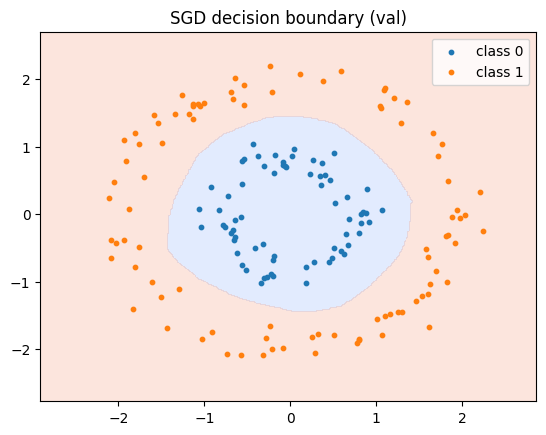

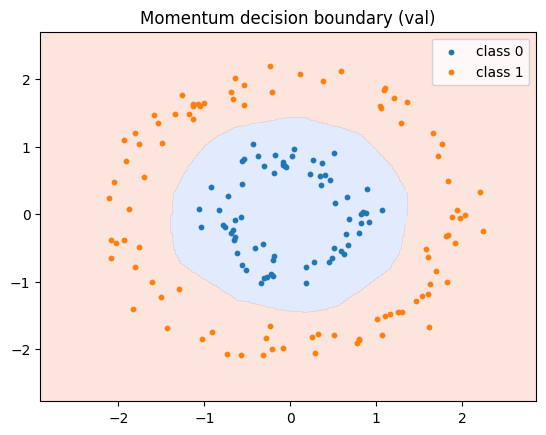

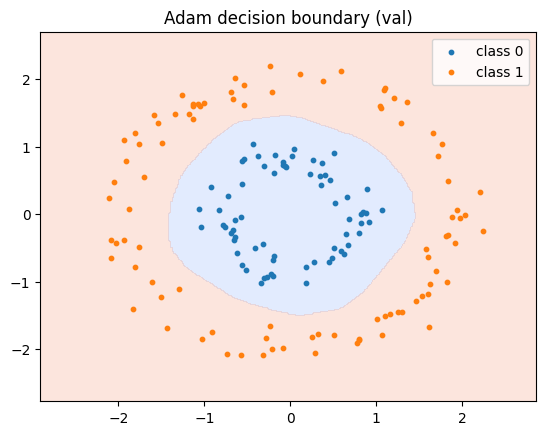

In [7]:
def plot_boundary(p, title):
    x_min,x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min,y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx,yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    P,_ = forward(grid, p)
    Z = P.argmax(1).reshape(xx.shape)
    plt.contourf(xx,yy,Z,alpha=0.25, levels=[-0.5,0.5,1.5], cmap='coolwarm')
    plt.scatter(Xte[yte==0,0], Xte[yte==0,1], s=10, label='class 0')
    plt.scatter(Xte[yte==1,0], Xte[yte==1,1], s=10, label='class 1')
    plt.legend(); plt.title(title); plt.show()
 
for name, (p, _) in results.items():
    plot_boundary(p, f"{name} decision boundary (val)")

7) Notes & tips
Learning rate matters: if loss explodes/plateaus, lower/increase lr.

Momentum damps oscillations; typical β≈0.9.

Adam adapts per‑parameter steps; default β1/β2 are fine (0.9/0.999).

With larger batches, you may raise lr. With stronger regularization (higher l2), you may also raise lr.